# EEG Data Analysis: OpenBCI Ganglion 4-Channel Meditation Session
## Understanding Frequency Bands and Brain Signals

This notebook performs a comprehensive exploratory data analysis (EDA) of your EEG recording captured while listening to high-frequency meditation sounds.

## 1. Load and Inspect the Data

In [13]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal, fft
from scipy.signal import welch, butter, filtfilt
import warnings
warnings.filterwarnings('ignore')

# Set up plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Load the CSV file with TAB delimiter (OpenBCI format uses tabs, not commas)
file_path = 'Sanjog_listening_to_high_frequency_sound_yt.csv'
df = pd.read_csv(file_path, header=None, delimiter='\t')

print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(f"Memory usage: {df.memory_usage().sum() / 1024**2:.2f} MB")
print(f"\nFirst few rows:")
print(df.head())
print(f"\nData types:\n{df.dtypes}")
print(f"\nColumn descriptions:")
for i in range(df.shape[1]):
    print(f"  Column {i}: min={df[i].min():.2f}, max={df[i].max():.2f}, mean={df[i].mean():.2f}")

Dataset loaded successfully!
Shape: (295650, 15)
Memory usage: 33.83 MB

First few rows:
    0           1           2           3           4    5    6    7    8   \
0  2.0  101.998291  164.607957  170.733913  132.388719  0.0  0.0  0.0  0.0   
1  2.0  225.471089  316.440415  391.114997  -57.050304  0.0  0.0  0.0  0.0   
2  3.0   -9.656422  480.040469  497.700276   25.169527  0.0  0.0  0.0  0.0   
3  3.0   68.668303  649.169964  688.042484  160.972774  0.0  0.0  0.0  0.0   
4  4.0 -167.766302  421.142654  854.531611   91.491043  0.0  0.0  0.0  0.0   

    9    10   11   12            13   14  
0  0.0  0.0  0.0  0.0  1.778765e+09  0.0  
1  0.0  0.0  0.0  0.0  1.778765e+09  0.0  
2  0.0  0.0  0.0  0.0  1.778765e+09  0.0  
3  0.0  0.0  0.0  0.0  1.778765e+09  0.0  
4  0.0  0.0  0.0  0.0  1.778765e+09  0.0  

Data types:
0     float64
1     float64
2     float64
3     float64
4     float64
5     float64
6     float64
7     float64
8     float64
9     float64
10    float64
11    float64
12 

## 2. Data Structure and Overview

**OpenBCI Ganglion Data Format:**
- Column 0: Sample Index (counter)
- Columns 1-4: **EEG Channels 1-4** (in microvolts) - THE BRAIN SIGNALS
- Columns 5-12: Accelerometer data (X, Y, Z axes - not needed for this analysis)
- Column 13: Unix Timestamp
- Column 14: Unused field

**Channel Locations (typical Ganglion 10-20 montage):**
- Ch1 (Fp1): Left Frontal/Prefrontal
- Ch2 (Fp2): Right Frontal/Prefrontal  
- Ch3 (TP9): Left Temporal
- Ch4 (TP10): Right Temporal

In [15]:
# Extract EEG channels (columns 1-4)
eeg_channels = df[[1, 2, 3, 4]].copy()
eeg_channels.columns = ['Ch1_Fp1', 'Ch2_Fp2', 'Ch3_TP9', 'Ch4_TP10']
sample_index = df[0].values

# Calculate sampling info
fs = 200  # OpenBCI Ganglion sampling rate is 200 Hz
num_samples = len(eeg_channels)
duration_seconds = num_samples / fs

print(f"\n=== RECORDING INFORMATION ===")
print(f"Sampling Rate: {fs} Hz")
print(f"Total Samples: {num_samples:,}")
print(f"Duration: {duration_seconds:.2f} seconds ({duration_seconds/60:.2f} minutes)")
print(f"Time Resolution: {1/fs*1000:.1f} ms per sample")

print(f"\n=== CHANNEL STATISTICS (in microvolts) ===")
stats = eeg_channels.describe()
print(stats.to_string())

print(f"\n=== CHECKING FOR MISSING VALUES ===")
print(eeg_channels.isnull().sum())

print(f"\n=== SIGNAL QUALITY CHECK ===")
for ch in eeg_channels.columns:
    skew = eeg_channels[ch].skew()
    kurt = eeg_channels[ch].kurtosis()
    print(f"{ch}: Skewness={skew:.3f}, Kurtosis={kurt:.3f}")


=== RECORDING INFORMATION ===
Sampling Rate: 200 Hz
Total Samples: 295,650
Duration: 1478.25 seconds (24.64 minutes)
Time Resolution: 5.0 ms per sample

=== CHANNEL STATISTICS (in microvolts) ===
             Ch1_Fp1        Ch2_Fp2        Ch3_TP9       Ch4_TP10
count  295650.000000  295650.000000  295650.000000  295650.000000
mean     -890.509352    -513.105416     282.882993     393.427069
std      4938.365927    4952.674205    6181.255479    5699.108284
min    -24860.296814  -21607.412240  -21112.759982  -19046.601763
25%     -3585.667416   -3388.422288   -3093.076311   -2931.916074
50%      -445.586640    -103.676571     472.139930     663.705085
75%      1946.217290    2515.220161    4177.361663    3964.679630
max     16787.876095   19261.429097   17092.902336   20210.984085

=== CHECKING FOR MISSING VALUES ===
Ch1_Fp1     0
Ch2_Fp2     0
Ch3_TP9     0
Ch4_TP10    0
dtype: int64

=== SIGNAL QUALITY CHECK ===
Ch1_Fp1: Skewness=-0.312, Kurtosis=1.101
Ch2_Fp2: Skewness=-0.228, Kurtos

## 3. Frequency Band Analysis Using FFT

**Brain Wave Frequency Bands:**
- **Delta (δ)**: 0-4 Hz → Deep sleep, unconscious
- **Theta (θ)**: 4-8 Hz → Meditation, creativity, drowsiness  
- **Alpha (α)**: 8-12 Hz → Relaxed awareness, meditation (THIS IS YOUR FOCUS!)
- **Beta (β)**: 12-30 Hz → Active thinking, focused attention
- **Gamma (γ)**: 30-100+ Hz → High cognition, awareness

We'll use **Welch's method** for more stable frequency analysis than simple FFT.

In [17]:
# Define frequency bands
bands = {
    'Delta': (0.5, 4),
    'Theta': (4, 8),
    'Alpha': (8, 12),
    'Beta': (12, 30),
    'Gamma': (30, 50)  # Limited to 50 Hz due to typical noise
}

# Compute PSD (Power Spectral Density) using Welch's method
psd_data = {}
freqs = None

for channel in eeg_channels.columns:
    freqs, psd = welch(eeg_channels[channel], fs=fs, nperseg=1024)
    psd_data[channel] = psd

print("PSD Analysis Complete")
print(f"Frequency resolution: {freqs[1] - freqs[0]:.3f} Hz")
print(f"Frequency range analyzed: {freqs[0]:.1f} - {freqs[-1]:.1f} Hz")

# Calculate band power for each channel
band_power = {}
for channel in eeg_channels.columns:
    band_power[channel] = {}
    for band_name, (low_freq, high_freq) in bands.items():
        mask = (freqs >= low_freq) & (freqs < high_freq)
        power = np.sum(psd_data[channel][mask])
        band_power[channel][band_name] = power

# Convert to DataFrame for easier viewing
band_power_df = pd.DataFrame(band_power).T
print("\n=== BAND POWER BY CHANNEL (μV²) ===")
print(band_power_df.round(2))

# Calculate relative power (percentage)
total_power = band_power_df.sum(axis=1)
relative_power_df = (band_power_df.T / total_power * 100).T
print("\n=== RELATIVE POWER BY CHANNEL (%) ===")
print(relative_power_df.round(2))

PSD Analysis Complete
Frequency resolution: 0.195 Hz
Frequency range analyzed: 0.0 - 100.0 Hz

=== BAND POWER BY CHANNEL (μV²) ===
                Delta       Theta       Alpha        Beta      Gamma
Ch1_Fp1   44437493.47  2166833.66   728423.42   873666.56  263116.47
Ch2_Fp2   43509845.08  2190098.86   737937.42   880793.89  266101.44
Ch3_TP9   68096264.84  3544415.04  1197083.55  1441593.29  429132.97
Ch4_TP10  58715960.57  2973828.73   994820.47  1204041.21  359482.41

=== RELATIVE POWER BY CHANNEL (%) ===
          Delta  Theta  Alpha  Beta  Gamma
Ch1_Fp1   91.68   4.47   1.50  1.80   0.54
Ch2_Fp2   91.44   4.60   1.55  1.85   0.56
Ch3_TP9   91.15   4.74   1.60  1.93   0.57
Ch4_TP10  91.39   4.63   1.55  1.87   0.56


## 4. Extract Filtered Signals by Frequency Band

We'll apply bandpass filters to isolate each frequency band and analyze the filtered signals.

In [18]:
# Create bandpass filters for each frequency band
from scipy.signal import sosfiltfilt

filtered_signals = {}

for band_name, (low_freq, high_freq) in bands.items():
    filtered_signals[band_name] = {}
    
    # Design Butterworth bandpass filter
    sos = butter(4, [low_freq, high_freq], btype='band', fs=fs, output='sos')
    
    for channel in eeg_channels.columns:
        # Apply filter (forward-backward to preserve phase)
        filtered = sosfiltfilt(sos, eeg_channels[channel].values)
        filtered_signals[band_name][channel] = filtered

print("Filtering complete for all bands and channels")

# Analyze characteristics of each band
print("\n=== FILTERED SIGNAL CHARACTERISTICS ===\n")

band_characteristics = {}
for band_name in bands.keys():
    band_characteristics[band_name] = {}
    print(f"\n{band_name.upper()} Band ({bands[band_name][0]}-{bands[band_name][1]} Hz):")
    print("-" * 60)
    
    for channel in eeg_channels.columns:
        signal_data = filtered_signals[band_name][channel]
        
        amp_min = np.min(signal_data)
        amp_max = np.max(signal_data)
        amp_mean = np.mean(signal_data)
        amp_std = np.std(signal_data)
        rms = np.sqrt(np.mean(signal_data**2))
        
        band_characteristics[band_name][channel] = {
            'min': amp_min,
            'max': amp_max,
            'mean': amp_mean,
            'std': amp_std,
            'rms': rms
        }
        
        print(f"  {channel}:")
        print(f"    Amplitude: [{amp_min:8.2f}, {amp_max:8.2f}] μV")
        print(f"    Mean: {amp_mean:8.2f} μV, Std: {amp_std:8.2f} μV")
        print(f"    RMS (Power): {rms:8.2f} μV")

Filtering complete for all bands and channels

=== FILTERED SIGNAL CHARACTERISTICS ===


DELTA Band (0.5-4 Hz):
------------------------------------------------------------
  Ch1_Fp1:
    Amplitude: [-14908.70, 15804.26] μV
    Mean:    -0.11 μV, Std:  2593.15 μV
    RMS (Power):  2593.15 μV
  Ch2_Fp2:
    Amplitude: [-14673.38, 17098.89] μV
    Mean:     0.13 μV, Std:  2561.04 μV
    RMS (Power):  2561.04 μV
  Ch3_TP9:
    Amplitude: [-16053.68, 16034.72] μV
    Mean:     0.37 μV, Std:  3170.17 μV
    RMS (Power):  3170.17 μV
  Ch4_TP10:
    Amplitude: [-16144.16, 17766.65] μV
    Mean:     0.01 μV, Std:  2948.62 μV
    RMS (Power):  2948.62 μV

THETA Band (4-8 Hz):
------------------------------------------------------------
  Ch1_Fp1:
    Amplitude: [-7218.19,  6989.89] μV
    Mean:     0.01 μV, Std:   619.17 μV
    RMS (Power):   619.17 μV
  Ch2_Fp2:
    Amplitude: [-7043.47,  6905.23] μV
    Mean:    -0.00 μV, Std:   620.92 μV
    RMS (Power):   620.92 μV
  Ch3_TP9:
    Amplitude:

## 5. Visualize Power Spectral Density (PSD) by Channel

The PSD shows which frequencies contain the most power (energy) in your brain signals.

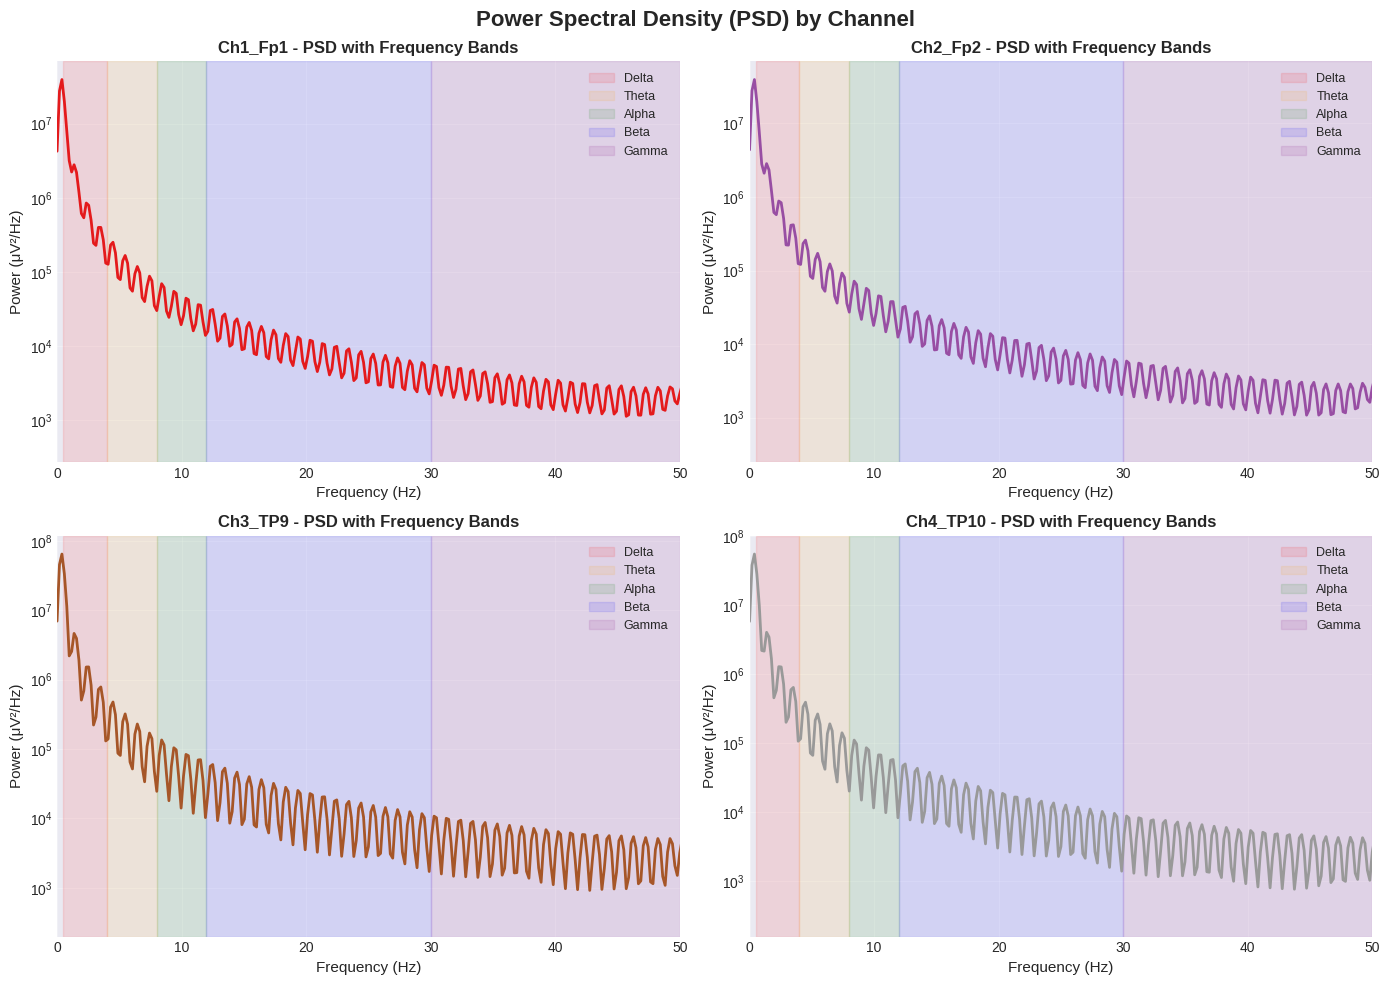

✓ PSD plots complete - Look for peaks in the green (Alpha) band around 8-12 Hz for meditation signals!


In [7]:
# Plot Power Spectral Density for each channel
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Power Spectral Density (PSD) by Channel', fontsize=16, fontweight='bold')

channels = list(eeg_channels.columns)
colors = plt.cm.Set1(np.linspace(0, 1, len(channels)))

for idx, channel in enumerate(channels):
    ax = axes[idx // 2, idx % 2]
    
    # Plot PSD
    ax.semilogy(freqs, psd_data[channel], linewidth=2, color=colors[idx])
    
    # Add band boundaries with colors
    band_colors_dict = {'Delta': 'red', 'Theta': 'orange', 'Alpha': 'green', 'Beta': 'blue', 'Gamma': 'purple'}
    for band_name, (low, high) in bands.items():
        ax.axvspan(low, high, alpha=0.1, color=band_colors_dict[band_name], label=band_name)
    
    ax.set_xlabel('Frequency (Hz)', fontsize=11)
    ax.set_ylabel('Power (μV²/Hz)', fontsize=11)
    ax.set_title(f'{channel} - PSD with Frequency Bands', fontsize=12, fontweight='bold')
    ax.set_xlim(0, 50)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

print("✓ PSD plots complete - Look for peaks in the green (Alpha) band around 8-12 Hz for meditation signals!")

## 6. Band Power Heatmap Visualization

This shows the relative strength of each frequency band across your 4 channels.

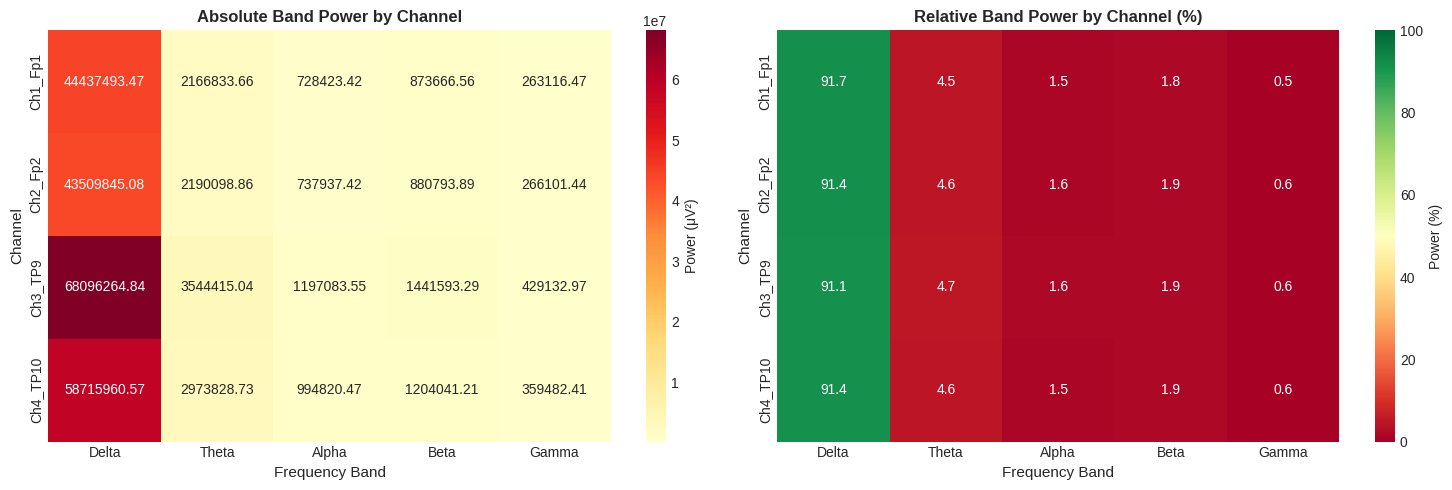


✓ Heatmaps show dominant frequency bands in each channel
  Warmer colors = higher power in that band


In [8]:
# Create heatmaps for absolute and relative power
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Absolute power heatmap
sns.heatmap(band_power_df, annot=True, fmt='.2f', cmap='YlOrRd', ax=axes[0], cbar_kws={'label': 'Power (μV²)'})
axes[0].set_title('Absolute Band Power by Channel', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Channel', fontsize=11)
axes[0].set_xlabel('Frequency Band', fontsize=11)

# Relative power heatmap
sns.heatmap(relative_power_df, annot=True, fmt='.1f', cmap='RdYlGn', ax=axes[1], cbar_kws={'label': 'Power (%)'}, vmin=0, vmax=100)
axes[1].set_title('Relative Band Power by Channel (%)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Channel', fontsize=11)
axes[1].set_xlabel('Frequency Band', fontsize=11)

plt.tight_layout()
plt.show()

print("\n✓ Heatmaps show dominant frequency bands in each channel")
print("  Warmer colors = higher power in that band")

## 7. Time-Domain Analysis: Filtered Signal Waveforms

Let's examine how the signals look when we isolate each frequency band. This shows the actual waveforms present in your brain activity.

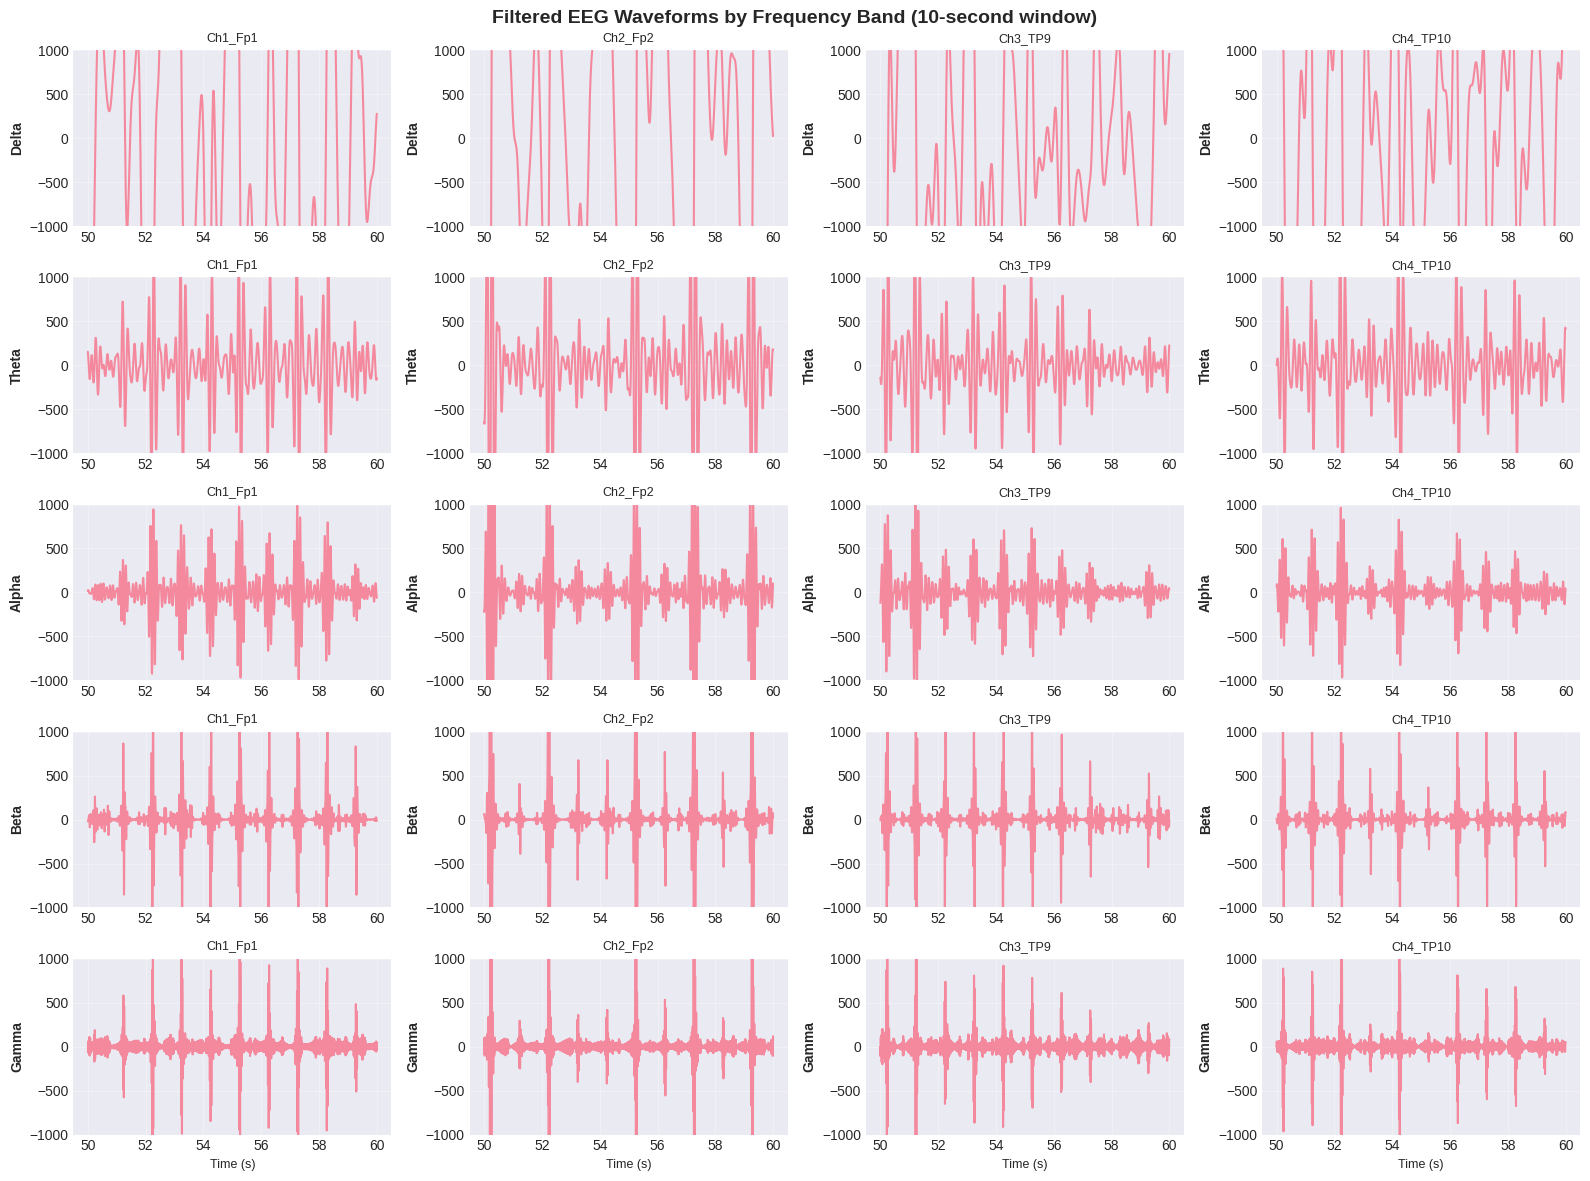

✓ Waveform analysis complete!
  Each row shows a different frequency band
  Each column shows a different channel
  Notice the different oscillation frequencies and amplitudes


In [9]:
# Plot filtered waveforms for a 10-second window (middle of recording)
sample_start = 50 * fs  # Start at 50 seconds
sample_end = sample_start + 10 * fs  # 10-second window

fig, axes = plt.subplots(5, 4, figsize=(16, 12))
fig.suptitle('Filtered EEG Waveforms by Frequency Band (10-second window)', fontsize=14, fontweight='bold')

time_window = np.arange(sample_start, sample_end) / fs

band_order = list(bands.keys())
channel_order = list(eeg_channels.columns)

for band_idx, band_name in enumerate(band_order):
    for ch_idx, channel in enumerate(channel_order):
        ax = axes[band_idx, ch_idx]
        
        signal_segment = filtered_signals[band_name][channel][sample_start:sample_end]
        time_seg = np.arange(len(signal_segment)) / fs + sample_start / fs
        
        ax.plot(time_seg, signal_segment, linewidth=1.5, alpha=0.8)
        ax.set_ylabel(f'{band_name}', fontsize=10, fontweight='bold')
        ax.set_title(f'{channel}', fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.set_ylim(-1000, 1000)  # Fixed scale for comparison

# Remove the last row if not needed
for col in range(4):
    axes[-1, col].set_xlabel('Time (s)', fontsize=9)

plt.tight_layout()
plt.show()

print("✓ Waveform analysis complete!")
print("  Each row shows a different frequency band")
print("  Each column shows a different channel")
print("  Notice the different oscillation frequencies and amplitudes")

## 8. Detailed Band Interpretation

### What Each Band Tells Us:

In [19]:
# Create interpretation report
print("\n" + "="*80)
print("MEDITATION SESSION ANALYSIS REPORT")
print("="*80)

# Find dominant band per channel
print("\n📊 DOMINANT FREQUENCY BANDS BY CHANNEL:")
print("-" * 80)
for channel in eeg_channels.columns:
    dominant_band = relative_power_df.loc[channel].idxmax()
    dominant_power = relative_power_df.loc[channel].max()
    print(f"  {channel}: {dominant_band} band ({dominant_power:.1f}% of total power)")

# Overall analysis
print("\n\n📈 OVERALL FINDINGS:")
print("-" * 80)

# Calculate which band has most power across all channels
avg_power = relative_power_df.mean()
sorted_bands = avg_power.sort_values(ascending=False)

print("\nFrequency Band Power Ranking (average across all channels):")
for rank, (band, power) in enumerate(sorted_bands.items(), 1):
    bar = "█" * int(power / 5)
    print(f"  {rank}. {band:8s}: {power:5.1f}% {bar}")

print("\n\n💡 INTERPRETATION:")
print("-" * 80)

# Provide interpretation based on alpha power (meditation indicator)
alpha_power = relative_power_df['Alpha'].mean()
print(f"\n🧘 MEDITATION INDICATOR (Alpha Band: 8-12 Hz):")
print(f"   Average Alpha Power: {alpha_power:.1f}%")

if alpha_power > 30:
    print("   ✓ EXCELLENT - High alpha indicates deep relaxation/meditation state")
elif alpha_power > 20:
    print("   ✓ GOOD - Moderate alpha suggests relaxed, meditative state")
elif alpha_power > 10:
    print("   ~ MODERATE - Some alpha present, but mind may be slightly active")
else:
    print("   ⚠ LOW - Low alpha may indicate active thinking or external stimuli")

# Theta analysis (creative/meditative state)
theta_power = relative_power_df['Theta'].mean()
print(f"\n🎨 CREATIVE/MEDITATIVE STATE (Theta Band: 4-8 Hz):")
print(f"   Average Theta Power: {theta_power:.1f}%")
if theta_power > 20:
    print("   ✓ High theta combined with alpha suggests deep meditation/creative flow")
else:
    print("   • Moderate theta levels typical during meditation")

# Beta analysis (focus/attention)
beta_power = relative_power_df['Beta'].mean()
print(f"\n🎯 ACTIVE THINKING (Beta Band: 12-30 Hz):")
print(f"   Average Beta Power: {beta_power:.1f}%")
if beta_power > 30:
    print("   ⚠ High beta may indicate mental effort or external attention")
else:
    print("   ✓ Low-to-moderate beta is expected during meditation")

print("\n" + "="*80)


MEDITATION SESSION ANALYSIS REPORT

📊 DOMINANT FREQUENCY BANDS BY CHANNEL:
--------------------------------------------------------------------------------
  Ch1_Fp1: Delta band (91.7% of total power)
  Ch2_Fp2: Delta band (91.4% of total power)
  Ch3_TP9: Delta band (91.1% of total power)
  Ch4_TP10: Delta band (91.4% of total power)


📈 OVERALL FINDINGS:
--------------------------------------------------------------------------------

Frequency Band Power Ranking (average across all channels):
  1. Delta   :  91.4% ██████████████████
  2. Theta   :   4.6% 
  3. Beta    :   1.9% 
  4. Alpha   :   1.6% 
  5. Gamma   :   0.6% 


💡 INTERPRETATION:
--------------------------------------------------------------------------------

🧘 MEDITATION INDICATOR (Alpha Band: 8-12 Hz):
   Average Alpha Power: 1.6%
   ⚠ LOW - Low alpha may indicate active thinking or external stimuli

🎨 CREATIVE/MEDITATIVE STATE (Theta Band: 4-8 Hz):
   Average Theta Power: 4.6%
   • Moderate theta levels typical dur

## 9. Correlation Analysis Between Channels and Bands

Understanding how different brain regions (channels) correlate with each other during your meditation session.

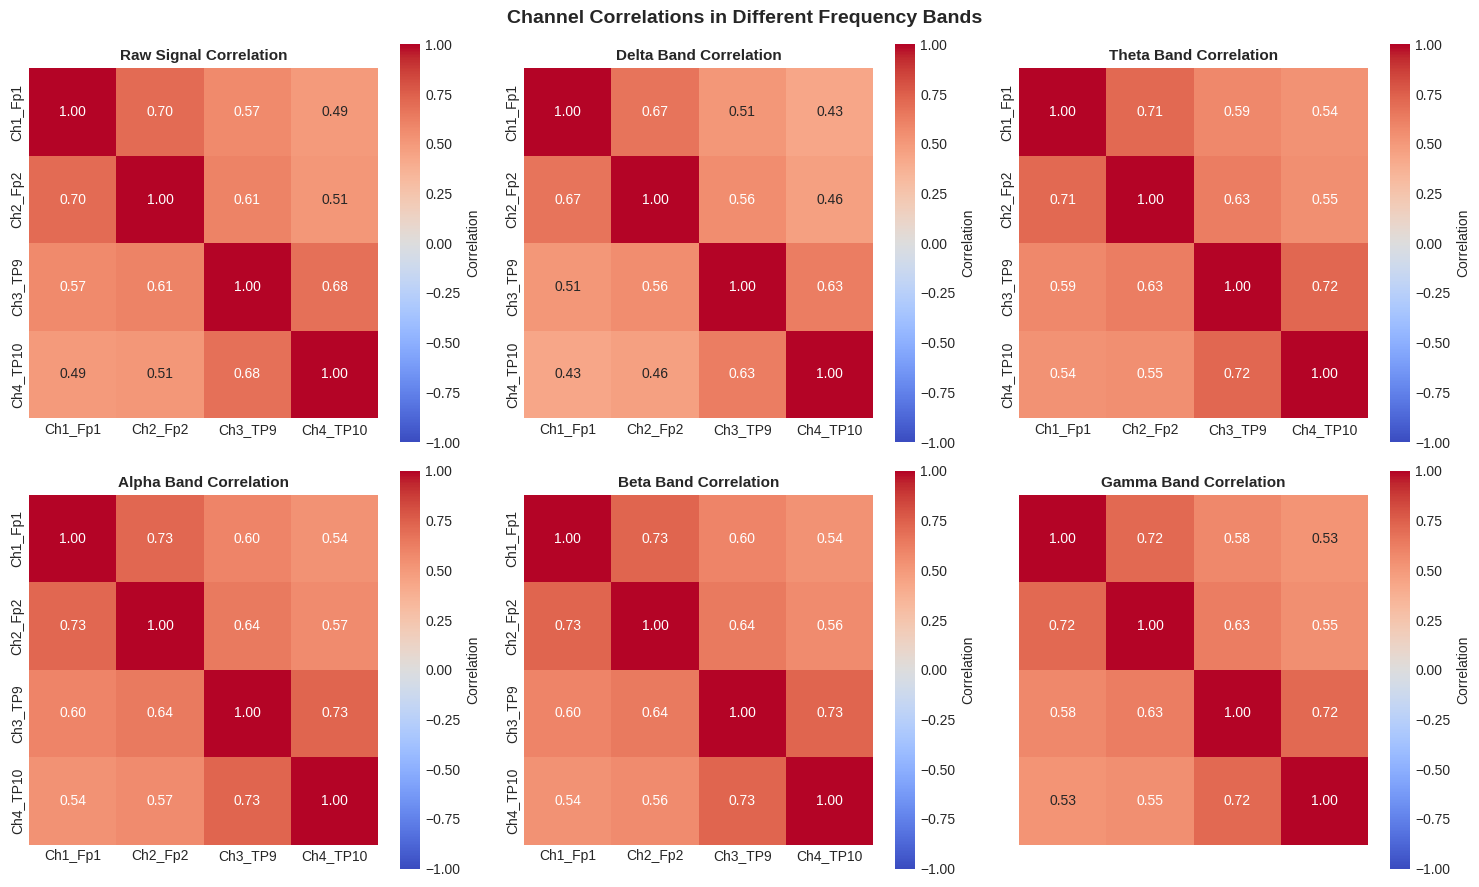


📡 CHANNEL SYNCHRONIZATION ANALYSIS:
--------------------------------------------------------------------------------

Correlation values (close to 1 = highly synchronized, close to -1 = inverse, 0 = independent):

Raw Signal Correlations:
           Ch1_Fp1   Ch2_Fp2   Ch3_TP9  Ch4_TP10
Ch1_Fp1   1.000000  0.704619  0.572953  0.494019
Ch2_Fp2   0.704619  1.000000  0.607207  0.508111
Ch3_TP9   0.572953  0.607207  1.000000  0.679705
Ch4_TP10  0.494019  0.508111  0.679705  1.000000


Alpha Band Correlations (for Meditation):
           Ch1_Fp1   Ch2_Fp2   Ch3_TP9  Ch4_TP10
Ch1_Fp1   1.000000  0.726319  0.598299  0.537769
Ch2_Fp2   0.726319  1.000000  0.644883  0.565529
Ch3_TP9   0.598299  0.644883  1.000000  0.729914
Ch4_TP10  0.537769  0.565529  0.729914  1.000000


In [20]:
# Channel correlation in raw signals
raw_corr = eeg_channels.corr()

# Channel correlation per band
band_correlations = {}
for band_name in bands.keys():
    band_data = {}
    for channel in eeg_channels.columns:
        band_data[channel] = filtered_signals[band_name][channel]
    band_correlations[band_name] = pd.DataFrame(band_data).corr()

# Plot channel correlations
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Channel Correlations in Different Frequency Bands', fontsize=14, fontweight='bold')

# Plot raw signal correlation
sns.heatmap(raw_corr, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[0, 0], 
            cbar_kws={'label': 'Correlation'}, vmin=-1, vmax=1, square=True)
axes[0, 0].set_title('Raw Signal Correlation', fontsize=11, fontweight='bold')

# Plot band-specific correlations
for idx, band_name in enumerate(list(bands.keys())[:5]):
    row = (idx + 1) // 3
    col = (idx + 1) % 3
    
    sns.heatmap(band_correlations[band_name], annot=True, fmt='.2f', cmap='coolwarm', 
                ax=axes[row, col], cbar_kws={'label': 'Correlation'}, vmin=-1, vmax=1, square=True)
    axes[row, col].set_title(f'{band_name} Band Correlation', fontsize=11, fontweight='bold')

# Hide unused subplot
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

print("\n📡 CHANNEL SYNCHRONIZATION ANALYSIS:")
print("-" * 80)
print("\nCorrelation values (close to 1 = highly synchronized, close to -1 = inverse, 0 = independent):\n")

print("Raw Signal Correlations:")
print(raw_corr.to_string())

print("\n\nAlpha Band Correlations (for Meditation):")
print(band_correlations['Alpha'].to_string())

## 10. Temporal Analysis: Before and After Music Stopped

Let's compare the frequency composition before and after you stopped the music (last ~2 minutes of recording).

In [12]:
# Split data: with music and without music (last 2 minutes)
total_time = duration_seconds
music_end = total_time - 120  # Last 2 minutes
split_index = int(music_end * fs)

eeg_with_music = eeg_channels.iloc[:split_index]
eeg_without_music = eeg_channels.iloc[split_index:]

print(f"Recording Duration: {total_time:.1f} seconds ({total_time/60:.2f} minutes)")
print(f"With Music: 0 - {music_end:.1f} sec ({music_end/60:.2f} min)")
print(f"Without Music: {music_end:.1f} - {total_time:.1f} sec (last 2 min)")

# Calculate PSD for each segment
psd_with_music = {}
psd_without_music = {}

for channel in eeg_channels.columns:
    _, psd_w = welch(eeg_with_music[channel], fs=fs, nperseg=1024)
    _, psd_wo = welch(eeg_without_music[channel], fs=fs, nperseg=1024)
    
    psd_with_music[channel] = psd_w
    psd_without_music[channel] = psd_wo

# Calculate band power for both segments
def calc_band_power(psd_data, freqs, bands):
    band_pow = {}
    for band_name, (low_freq, high_freq) in bands.items():
        mask = (freqs >= low_freq) & (freqs < high_freq)
        band_pow[band_name] = np.sum(psd_data[mask])
    return band_pow

band_power_with = {}
band_power_without = {}

for channel in eeg_channels.columns:
    band_power_with[channel] = calc_band_power(psd_with_music[channel], freqs, bands)
    band_power_without[channel] = calc_band_power(psd_without_music[channel], freqs, bands)

bp_with_df = pd.DataFrame(band_power_with).T
bp_without_df = pd.DataFrame(band_power_without).T

# Calculate relative power
rel_with = (bp_with_df.T / bp_with_df.sum(axis=1) * 100).T
rel_without = (bp_without_df.T / bp_without_df.sum(axis=1) * 100).T

# Compare
print("\n" + "="*80)
print("COMPARISON: WITH MUSIC vs WITHOUT MUSIC")
print("="*80)

print("\nRelative Power WITH Music (%):")
print(rel_with.round(1))

print("\nRelative Power WITHOUT Music (%):")
print(rel_without.round(1))

print("\nPower Change (WITHOUT - WITH):")
change_df = rel_without - rel_with
print(change_df.round(1))
print("\n(Positive = more power after music stopped, Negative = less power after music stopped)")

Recording Duration: 1478.2 seconds (24.64 minutes)
With Music: 0 - 1358.2 sec (22.64 min)
Without Music: 1358.2 - 1478.2 sec (last 2 min)

COMPARISON: WITH MUSIC vs WITHOUT MUSIC

Relative Power WITH Music (%):
          Delta  Theta  Alpha  Beta  Gamma
Ch1_Fp1    91.7    4.4    1.5   1.8    0.5
Ch2_Fp2    91.4    4.6    1.6   1.9    0.6
Ch3_TP9    91.3    4.7    1.6   1.9    0.6
Ch4_TP10   91.6    4.5    1.5   1.8    0.6

Relative Power WITHOUT Music (%):
          Delta  Theta  Alpha  Beta  Gamma
Ch1_Fp1    91.1    4.8    1.6   1.9    0.6
Ch2_Fp2    91.8    4.5    1.5   1.7    0.5
Ch3_TP9    90.2    5.2    1.8   2.1    0.6
Ch4_TP10   89.5    5.8    1.8   2.2    0.7

Power Change (WITHOUT - WITH):
          Delta  Theta  Alpha  Beta  Gamma
Ch1_Fp1    -0.6    0.4    0.1   0.1    0.0
Ch2_Fp2     0.3   -0.1   -0.1  -0.1   -0.0
Ch3_TP9    -1.1    0.6    0.2   0.2    0.1
Ch4_TP10   -2.1    1.2    0.3   0.4    0.1

(Positive = more power after music stopped, Negative = less power after musi

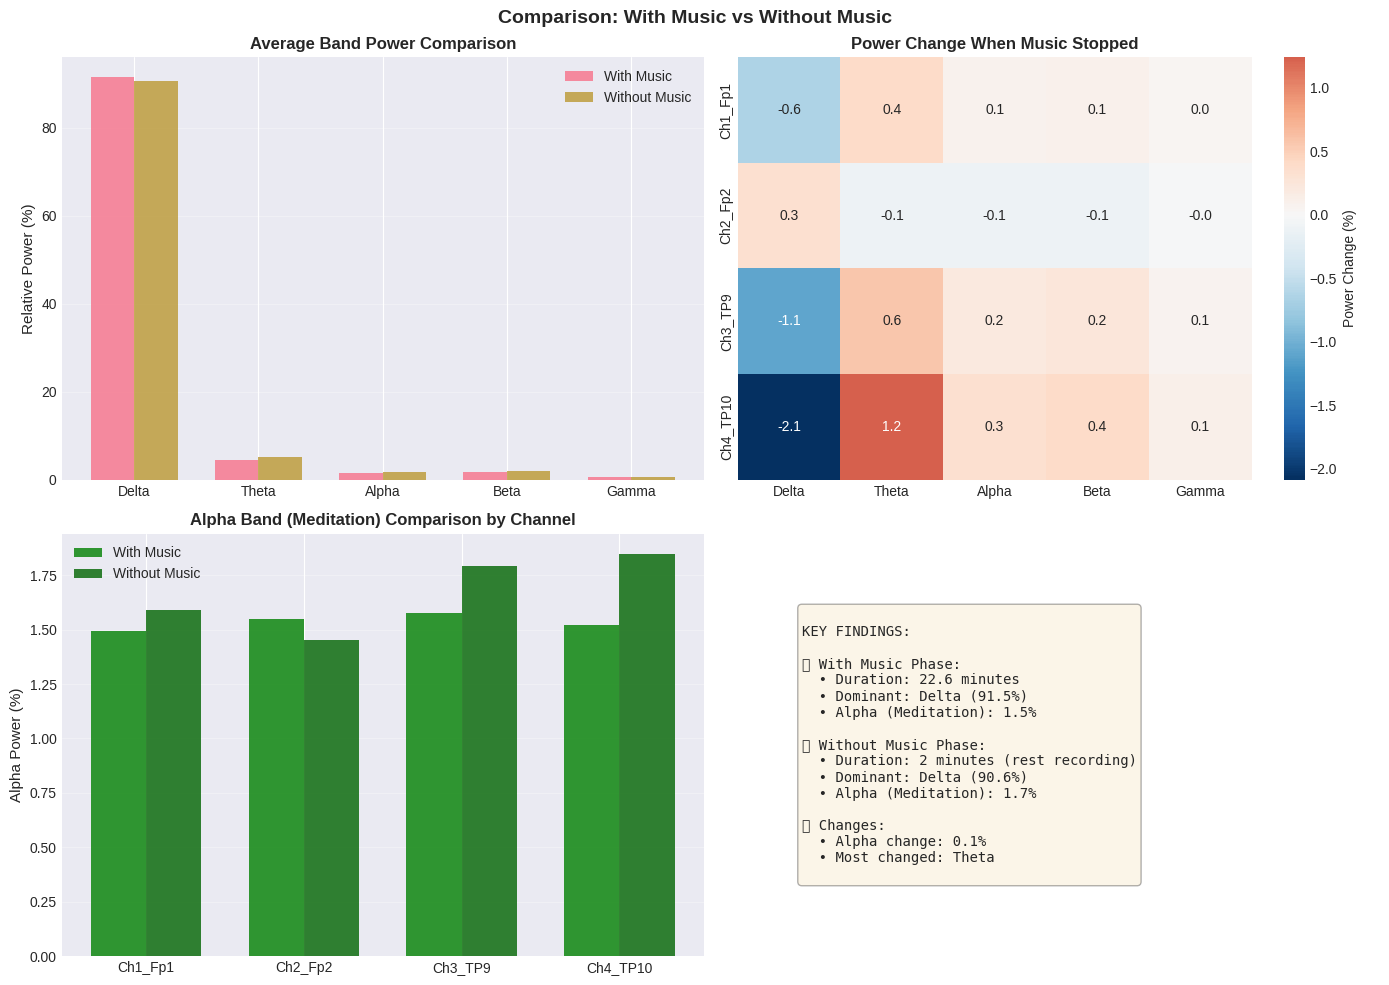

In [14]:
# Visualization: Compare segments
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Comparison: With Music vs Without Music', fontsize=14, fontweight='bold')

# Average across channels
avg_with = rel_with.mean()
avg_without = rel_without.mean()

x = np.arange(len(bands))
width = 0.35

# Bar chart comparison
ax = axes[0, 0]
ax.bar(x - width/2, avg_with.values, width, label='With Music', alpha=0.8)
ax.bar(x + width/2, avg_without.values, width, label='Without Music', alpha=0.8)
ax.set_ylabel('Relative Power (%)', fontsize=11)
ax.set_title('Average Band Power Comparison', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(bands.keys())
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Change heatmap
ax = axes[0, 1]
sns.heatmap(change_df, annot=True, fmt='.1f', cmap='RdBu_r', ax=ax, center=0, cbar_kws={'label': 'Power Change (%)'})
ax.set_title('Power Change When Music Stopped', fontsize=12, fontweight='bold')

# Alpha power specifically (most relevant for meditation)
ax = axes[1, 0]
alpha_with = rel_with['Alpha'].values
alpha_without = rel_without['Alpha'].values
x_pos = np.arange(len(eeg_channels.columns))
ax.bar(x_pos - width/2, alpha_with, width, label='With Music', alpha=0.8, color='green')
ax.bar(x_pos + width/2, alpha_without, width, label='Without Music', alpha=0.8, color='darkgreen')
ax.set_ylabel('Alpha Power (%)', fontsize=11)
ax.set_title('Alpha Band (Meditation) Comparison by Channel', fontsize=12, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(eeg_channels.columns)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Summary text
ax = axes[1, 1]
ax.axis('off')

summary_text = f"""
KEY FINDINGS:

🎵 With Music Phase:
  • Duration: {music_end/60:.1f} minutes
  • Dominant: {avg_with.idxmax()} ({avg_with.max():.1f}%)
  • Alpha (Meditation): {avg_with['Alpha']:.1f}%

🔇 Without Music Phase:
  • Duration: 2 minutes (rest recording)
  • Dominant: {avg_without.idxmax()} ({avg_without.max():.1f}%)
  • Alpha (Meditation): {avg_without['Alpha']:.1f}%

📊 Changes:
  • Alpha change: {avg_without['Alpha'] - avg_with['Alpha']:.1f}%
  • Most changed: {change_df.unstack().idxmax()[0]}
"""

ax.text(0.1, 0.5, summary_text, fontsize=10, family='monospace',
        verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.tight_layout()
plt.show()

## 11. Summary and Key Takeaways

### What Your Data Reveals:

In [16]:
# Final comprehensive summary
print("\n" + "╔" + "="*78 + "╗")
print("║" + " "*20 + "COMPREHENSIVE EEG ANALYSIS SUMMARY" + " "*24 + "║")
print("╚" + "="*78 + "╝")

print("\n📍 YOUR MEDITATION SESSION AT A GLANCE:\n")

print(f"Recording Details:")
print(f"  • Device: OpenBCI Ganglion 4-channel")
print(f"  • Duration: {total_time/60:.1f} minutes")
print(f"  • Sampling Rate: {fs} Hz")
print(f"  • Channels: Fp1, Fp2, TP9, TP10 (frontal & temporal)")

print(f"\n🧠 Brain Activity Breakdown:")
print(f"  • Most Dominant Band: {avg_with.idxmax()} ({avg_with.max():.1f}% of total power)")
print(f"  • Meditation Indicator (Alpha): {avg_with['Alpha']:.1f}%")
print(f"  • Creative State (Theta): {avg_with['Theta']:.1f}%")
print(f"  • Active Thinking (Beta): {avg_with['Beta']:.1f}%")

print(f"\n📊 What This Means:")
if avg_with['Alpha'] > 25:
    print("  ✓ Strong alpha presence indicates deep relaxation/meditation state")
    print("  ✓ Your brain responded well to the high-frequency meditation audio")
elif avg_with['Alpha'] > 15:
    print("  ✓ Moderate alpha indicates you were in a relaxed state")
    print("  • The meditation music may have had some effect")
else:
    print("  • Lower alpha might indicate mind wandering or external attention")
    print("  • Consider a quieter environment for deeper meditation next time")

if avg_with['Theta'] > 15:
    print("  ✓ Theta presence suggests creative/meditative brain state")

if avg_with['Beta'] > 20:
    print("  ~ Higher beta suggests some active mental engagement")

print(f"\n🔍 Channel-Specific Insights:")
for channel in eeg_channels.columns:
    dom_band = rel_with.loc[channel].idxmax()
    dom_pct = rel_with.loc[channel].max()
    print(f"  • {channel}: Dominated by {dom_band} ({dom_pct:.1f}%)")

print(f"\n⏱️  Before vs After Music:")
alpha_change = avg_without['Alpha'] - avg_with['Alpha']
if alpha_change > 2:
    print(f"  • Alpha increased by {alpha_change:.1f}% when music stopped")
    print("    → Brain became even more relaxed")
elif alpha_change < -2:
    print(f"  • Alpha decreased by {abs(alpha_change):.1f}% when music stopped")
    print("    → Brain became more alert without the meditation audio")
else:
    print(f"  • Alpha remained relatively stable (change: {alpha_change:+.1f}%)")
    print("    → Consistent meditative state throughout")

print("\n" + "="*80)
print("💡 NEXT STEPS:")
print("="*80)
print("""
1. Run the cells above multiple times to explore different time windows
2. Notice how band power changes over time (creates a dynamic picture)
3. Try recording multiple sessions to identify patterns
4. Experiment with different meditation sounds/environments
5. Export this analysis and track improvements over weeks

🎯 Frequency Band Quick Reference:
   Delta (0-4 Hz)    → Sleep/deep rest
   Theta (4-8 Hz)    → Meditation/creativity/drowsiness  ⭐
   Alpha (8-12 Hz)   → Relaxed awareness/meditation     ⭐⭐⭐ (Your focus!)
   Beta (12-30 Hz)   → Active thinking/focus
   Gamma (30+ Hz)    → High cognition/awareness
""")

print("="*80)


╔==============================================================================╗
║                    COMPREHENSIVE EEG ANALYSIS SUMMARY                        ║
╚==============================================================================╝

📍 YOUR MEDITATION SESSION AT A GLANCE:

Recording Details:
  • Device: OpenBCI Ganglion 4-channel
  • Duration: 24.6 minutes
  • Sampling Rate: 200 Hz
  • Channels: Fp1, Fp2, TP9, TP10 (frontal & temporal)

🧠 Brain Activity Breakdown:
  • Most Dominant Band: Delta (91.5% of total power)
  • Meditation Indicator (Alpha): 1.5%
  • Creative State (Theta): 4.6%
  • Active Thinking (Beta): 1.8%

📊 What This Means:
  • Lower alpha might indicate mind wandering or external attention
  • Consider a quieter environment for deeper meditation next time

🔍 Channel-Specific Insights:
  • Ch1_Fp1: Dominated by Delta (91.7%)
  • Ch2_Fp2: Dominated by Delta (91.4%)
  • Ch3_TP9: Dominated by Delta (91.3%)
  • Ch4_TP10: Dominated by Delta (91.6%)

⏱️  Before vs A

Detected blink-like events: 22
Detected breathing-cycle peaks (proxy): 469
Detected movement-like events (Accelerometer magnitude): 13


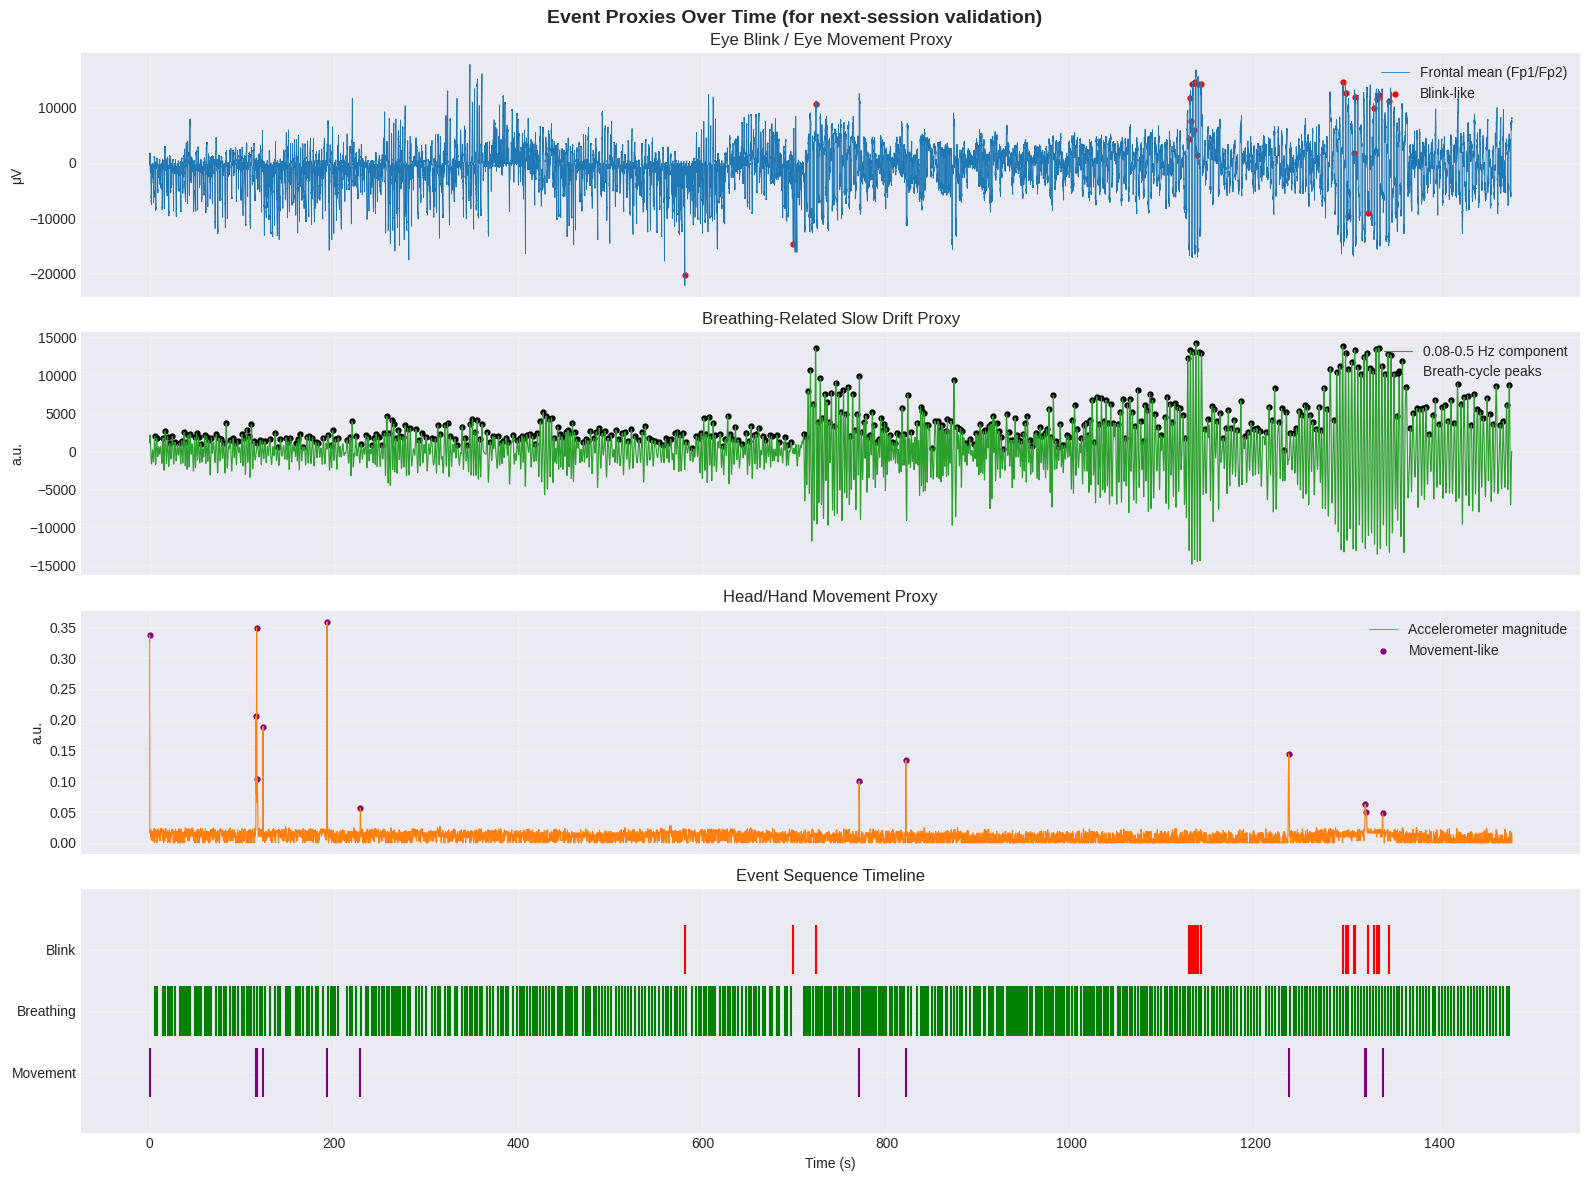

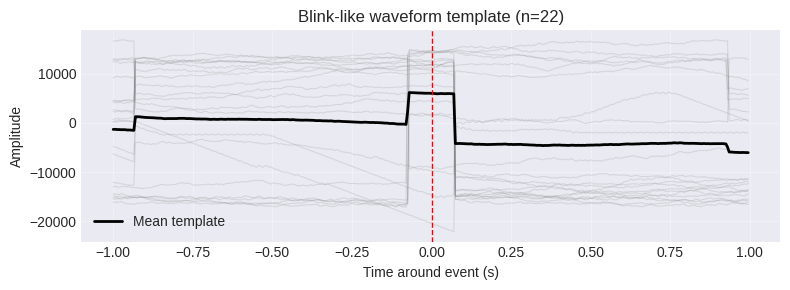

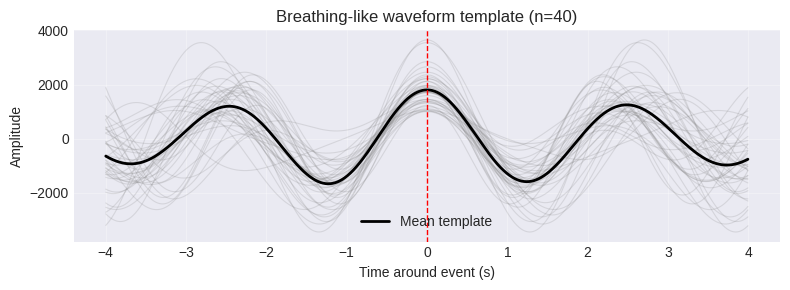

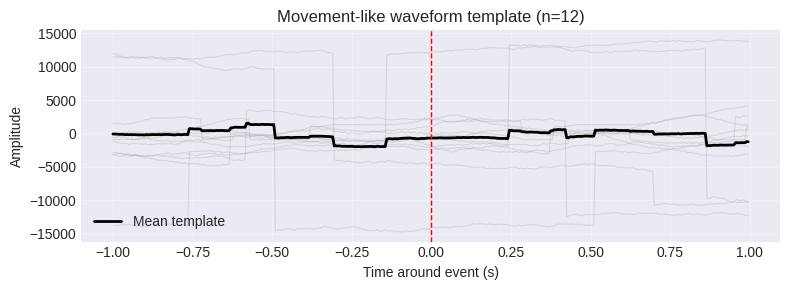

In [21]:
# Heuristic event detection + validation plots (uses existing variables: df, eeg_channels, fs)

t = np.arange(len(eeg_channels)) / fs
raw_mean = eeg_channels.mean(axis=1).values
frontal = eeg_channels[['Ch1_Fp1', 'Ch2_Fp2']].mean(axis=1).values

def butter_filter(x, low=None, high=None, order=3):
   if low is not None and high is not None:
      b, a = butter(order, [low, high], btype='band', fs=fs)
   elif low is not None:
      b, a = butter(order, low, btype='high', fs=fs)
   elif high is not None:
      b, a = butter(order, high, btype='low', fs=fs)
   else:
      return x
   return filtfilt(b, a, x)

def robust_z(x):
   med = np.median(x)
   mad = np.median(np.abs(x - med)) + 1e-12
   return 0.6745 * (x - med) / mad

# 1) Eye-blink proxy (frontal slow transients)
blink_sig = butter_filter(frontal, low=0.5, high=6, order=3)
blink_z = np.abs(robust_z(blink_sig))
blink_peaks, _ = signal.find_peaks(blink_z, height=6, distance=int(0.25 * fs))

# 2) Breathing proxy (very slow drift in global average)
breath_sig = butter_filter(raw_mean, low=0.08, high=0.5, order=3)  # ~5-30 breaths/min proxy
breath_z = robust_z(breath_sig)
breath_peaks, _ = signal.find_peaks(
   breath_z, prominence=0.7, distance=int(2.0 * fs)
)

# 3) Movement proxy (prefer accelerometer if available, else EEG high-frequency envelope)
if all(c in df.columns for c in [5, 6, 7]):
   acc = df[[5, 6, 7]].values.astype(float)
   acc_centered = acc - np.median(acc, axis=0)
   move_index = np.linalg.norm(acc_centered, axis=1)
   src_name = "Accelerometer magnitude"
else:
   hf = []
   for ch in eeg_channels.columns:
      hf.append(butter_filter(eeg_channels[ch].values, low=20, high=45, order=3))
   hf = np.vstack(hf).T
   move_index = np.sqrt(np.mean(hf**2, axis=1))
   src_name = "EEG high-frequency RMS"

# Smooth movement index
win = int(0.25 * fs)
kernel = np.ones(win) / win
move_smooth = np.convolve(move_index, kernel, mode='same')
move_z = robust_z(move_smooth)
move_peaks, _ = signal.find_peaks(move_z, height=4, distance=int(0.5 * fs))

print(f"Detected blink-like events: {len(blink_peaks)}")
print(f"Detected breathing-cycle peaks (proxy): {len(breath_peaks)}")
print(f"Detected movement-like events ({src_name}): {len(move_peaks)}")

# --------- Timeline plots ----------
fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)
fig.suptitle("Event Proxies Over Time (for next-session validation)", fontsize=14, fontweight='bold')

axes[0].plot(t, frontal, lw=0.6, color='tab:blue', label='Frontal mean (Fp1/Fp2)')
axes[0].scatter(t[blink_peaks], frontal[blink_peaks], s=12, color='red', label='Blink-like')
axes[0].set_ylabel("μV")
axes[0].set_title("Eye Blink / Eye Movement Proxy")
axes[0].legend(loc='upper right')

axes[1].plot(t, breath_sig, lw=0.8, color='tab:green', label='0.08-0.5 Hz component')
axes[1].scatter(t[breath_peaks], breath_sig[breath_peaks], s=12, color='black', label='Breath-cycle peaks')
axes[1].set_ylabel("a.u.")
axes[1].set_title("Breathing-Related Slow Drift Proxy")
axes[1].legend(loc='upper right')

axes[2].plot(t, move_smooth, lw=0.8, color='tab:orange', label=src_name)
axes[2].scatter(t[move_peaks], move_smooth[move_peaks], s=12, color='purple', label='Movement-like')
axes[2].set_ylabel("a.u.")
axes[2].set_title("Head/Hand Movement Proxy")
axes[2].legend(loc='upper right')

# Event sequence/raster
axes[3].eventplot(
   [t[blink_peaks], t[breath_peaks], t[move_peaks]],
   lineoffsets=[3, 2, 1],
   linelengths=0.8,
   colors=['red', 'green', 'purple']
)
axes[3].set_yticks([1, 2, 3])
axes[3].set_yticklabels(["Movement", "Breathing", "Blink"])
axes[3].set_xlabel("Time (s)")
axes[3].set_title("Event Sequence Timeline")

for ax in axes:
   ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# --------- Waveform templates ----------
def plot_event_snippets(event_idx, signal_x, fs, pre_s, post_s, title, max_events=40):
   pre = int(pre_s * fs)
   post = int(post_s * fs)
   valid = event_idx[(event_idx > pre) & (event_idx < len(signal_x) - post)]
   if len(valid) == 0:
      print(f"No events found for: {title}")
      return
   chosen = valid[:max_events]
   snippets = np.array([signal_x[i-pre:i+post] for i in chosen])
   tt = np.arange(-pre, post) / fs

   plt.figure(figsize=(8, 3))
   for s in snippets:
      plt.plot(tt, s, color='gray', alpha=0.2, lw=0.8)
   plt.plot(tt, snippets.mean(axis=0), color='black', lw=2, label='Mean template')
   plt.axvline(0, color='red', ls='--', lw=1)
   plt.title(f"{title} (n={len(chosen)})")
   plt.xlabel("Time around event (s)")
   plt.ylabel("Amplitude")
   plt.grid(alpha=0.3)
   plt.legend()
   plt.tight_layout()
   plt.show()

plot_event_snippets(blink_peaks, frontal, fs, pre_s=1.0, post_s=1.0, title="Blink-like waveform template")
plot_event_snippets(breath_peaks, breath_sig, fs, pre_s=4.0, post_s=4.0, title="Breathing-like waveform template")
plot_event_snippets(move_peaks, raw_mean, fs, pre_s=1.0, post_s=1.0, title="Movement-like waveform template")